In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyshtools as pysh
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import os 
from meshplot import plot, subplot 
import anndata as ad
import pandas as pd

import igl 
from scipy.sparse.linalg import eigsh
from scipy import sparse 
from tqdm import tqdm
from sklearn.neighbors import NearestNeighbors

from scipy.special import digamma, gamma

# Set OpenBLAS to single thread to avoid memory conflicts
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'

In [2]:
import importlib

import src.meshharm
import src.fatemarkers
importlib.reload(src.meshharm)
importlib.reload(src.fatemarkers)


from src import utils 
from src.fatemarkers import FateMarkers
from src.ksg_estimators import KSGEstimator

In [3]:
path = 'Data/20250714/fractal_output/'

timepoints = ['day1p5', 'day2', 'day2p5', 'day3', 'day3p5', 'day4', 'day4p5', 'day4p5-more']

zarr_names = {
        'day1p5': 'r0.zarr',
        'day2':'r0.zarr',
        'day2p5':'r0.zarr',
        'day3':'r0.zarr',
        'day3p5':'r0.zarr',
        'day4':'r0.zarr',
        'day4p5':'r0.zarr',
        'day4p5-more':'r0.zarr',
}


wells = {
    'day1p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day3': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'B02', 'B03'],
    'day3p5': ['A01', 'A02', 'A03', 'A04', 'B03'],
    'day4': ['A02', 'A03', 'A04', 'A05', 'A06', 'B01', 'B02'],
    'day4p5': ['A06', 'B06'],
    'day4p5-more': ['C01', 'C02', 'C03', 'C04', 'C05', 'C06'],
}

rounds = {
    'day1p5': ['0_fused_zillum'],
    'day2': ['0_fused_zillum'],
    'day2p5': ['0_fused_zillum'],
    'day3': ['0_fused_zillum'],
    'day3p5': ['0_fused_zillum'],
    'day4': ['0_fused_zillum'],
    'day4p5': ['0_fused_zillum'],
    'day4p5-more': ['0_fused_zillum'],
}
times_dic = {
    '1p5': 1.5,
    '2': 2,
    '2p5': 2.5,
    '3': 3,
    '3p5': 3.5,
    '4': 4,
    '4p5': 4.5,
    '4p5-more': 4.5
}

In [4]:
def load(save_path, ts=[1, 25, 100]): 
    m = FateMarkers()
    m.load_results(save_path)
    coeffs_hks = m.compute_hks_for_new_times(new_ts=ts)
    frac = m.compute_recon_quality()
    return m.coeffs_fm[:, 3:], coeffs_hks, frac

In [5]:
def compute_weights(lmax=15): 
    degree_labels = np.zeros(lmax**2, dtype=int)
    for i in range(lmax):
        degree_labels[i**2:(i+1)**2] = i
    # Create weights
    weights = 1.0 / (2 * degree_labels + 1)
    return weights 

def inner_product(coeffs1, coeffs2, weights):
    return np.sum(coeffs1 * np.conjugate(coeffs2) * weights)

In [ ]:
coeffs_hks = [] 
coeffs_fm = [] 
times = [] 
fracs = [] 

ts = [1, 4, 25, 64, 100]


for timepoint in timepoints:
    zarr_name = zarr_names[timepoint]
    for well_name in wells[timepoint]:
        round_name = rounds[timepoint][0]

        file_path = f"{path}{timepoint}/{zarr_name}/{well_name[0]}/{well_name[1:]}/{round_name}/"
        labels = np.load(file_path + 'good_labels.npy').astype('int')
        print(file_path) 
        for label in tqdm(labels[::10]):
            save_path = f"{file_path}/fm_data/{label}"
            if os.path.exists(save_path + '_coeffs.npz'):
                c1, c2, frac = load(save_path, ts=ts)
                coeffs_fm.append(c1)
                coeffs_hks.append(c2)
                times.append(timepoint[3:6])
                fracs.append(frac)

Data/20250714/fractal_output/day1p5/r0.zarr/A/01/0_fused_zillum/


100%|██████████| 12/12 [00:01<00:00,  9.30it/s]


Data/20250714/fractal_output/day1p5/r0.zarr/A/02/0_fused_zillum/


100%|██████████| 6/6 [00:00<00:00,  9.39it/s]


Data/20250714/fractal_output/day1p5/r0.zarr/A/03/0_fused_zillum/


...

100%|██████████| 10/10 [00:00<00:00, 15.47it/s]


Data/20250714/fractal_output/day4p5-more/r0.zarr/C/05/0_fused_zillum/


100%|██████████| 11/11 [00:00<00:00, 15.77it/s]


Data/20250714/fractal_output/day4p5-more/r0.zarr/C/06/0_fused_zillum/


100%|██████████| 14/14 [00:00<00:00, 15.75it/s]


In [63]:
threshold = np.percentile(fracs, 95)
recon_mask = np.array(fracs) < threshold
filtered_times = np.array(times)[recon_mask]
filtered_hks = np.array(coeffs_hks)[recon_mask]

In [76]:

coeffs_fm_filtered = np.array(coeffs_fm)[recon_mask]


coeffs = np.concatenate([np.array(coeffs_fm_filtered), filtered_hks], axis=-1)

names = ['LGR5 mean', 'LGR5 95 percentile', 
         'CHROMOGRANIN-A mean', 'CHROMOGRANIN-A 95 percentile', 
         'CYC-D1 mean', 'CYC-D1 95 percentile'] 

hks_names = [f'HKS t={i}' for i in ts]

names.extend(hks_names)

In [65]:
print(coeffs.shape) 

(341, 225, 11)


In [66]:
scaler = StandardScaler()
ksg = KSGEstimator()

matrices = [] 
for t in np.unique(times): 
    mask = (filtered_times == t) 
    print(int(np.sum(mask)), t)
    mi_matrix = np.zeros((coeffs.shape[-1], coeffs.shape[-1]))
    masked_coeffs = coeffs[mask, :, :] 
    for i in range(coeffs.shape[-1]): 
        for j in range(0, i+1): 

            X = np.copy(masked_coeffs[:, :, i])
            Y = np.copy(masked_coeffs[:, :, j])
            X = scaler.fit_transform(X)
            Y = scaler.fit_transform(Y)
            mi_matrix[i, j] = ksg.mutual_information(X, Y, method=2)
            mi_matrix[j, i] = mi_matrix[i, j]
    matrices.append(mi_matrix)


51 1p5
37 2
44 2p5
58 3
38 3p5
42 4
71 4p5


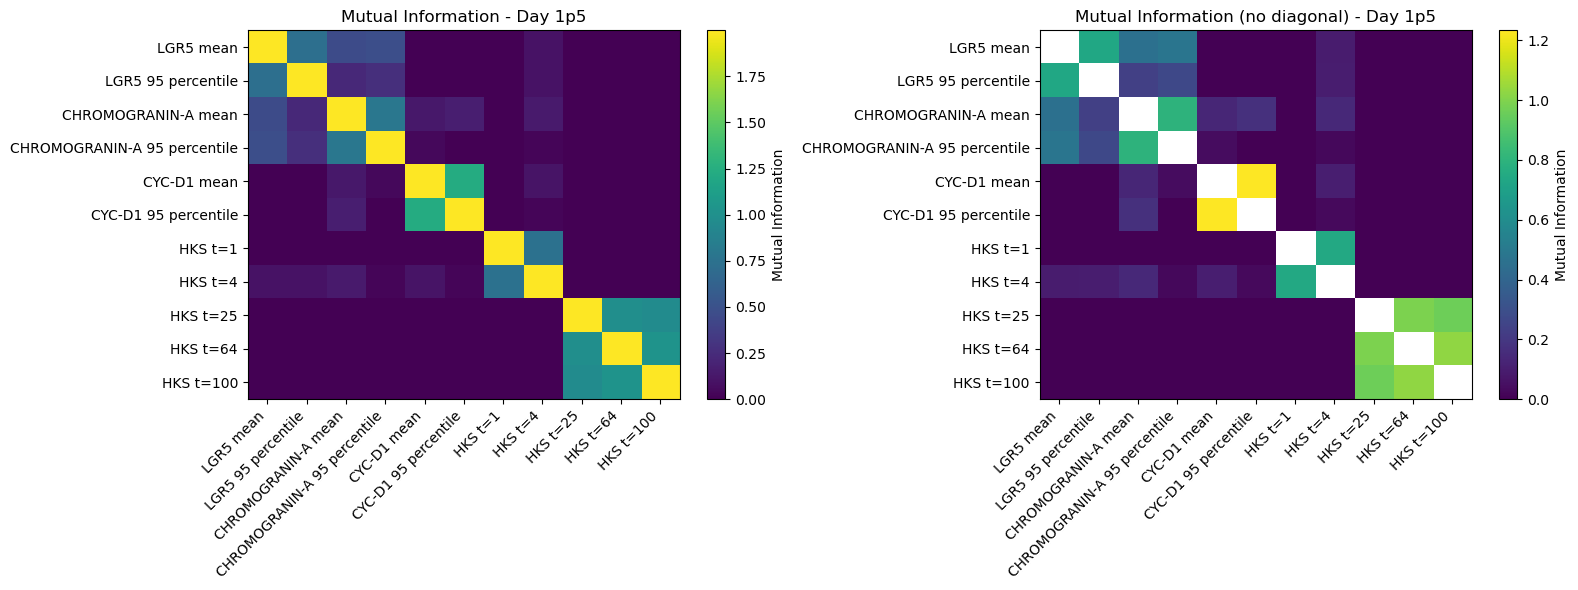

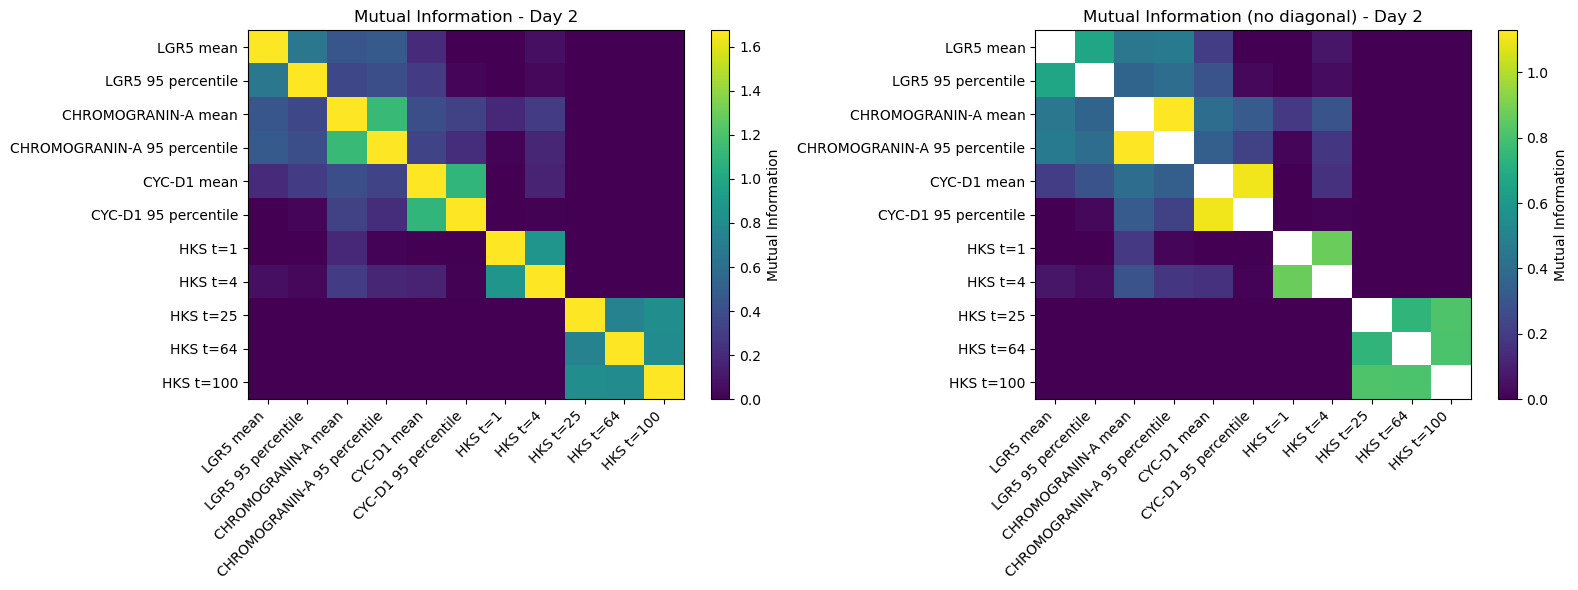

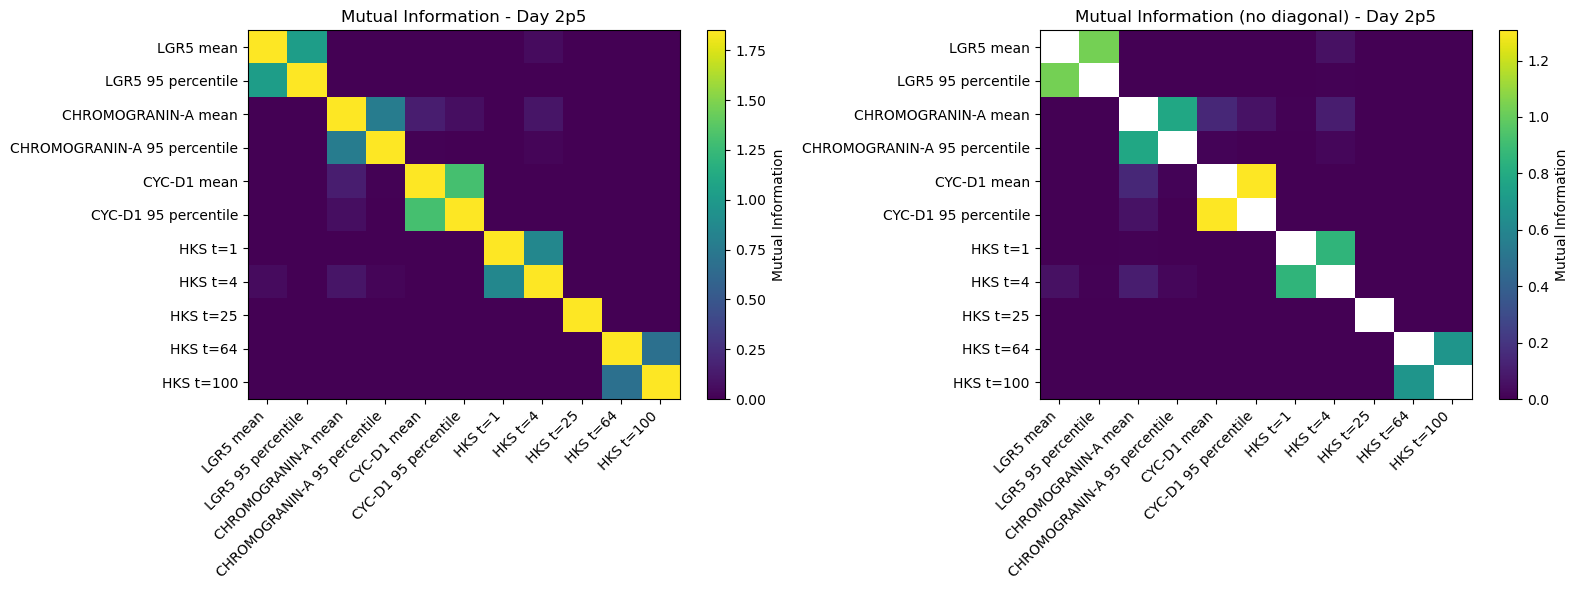

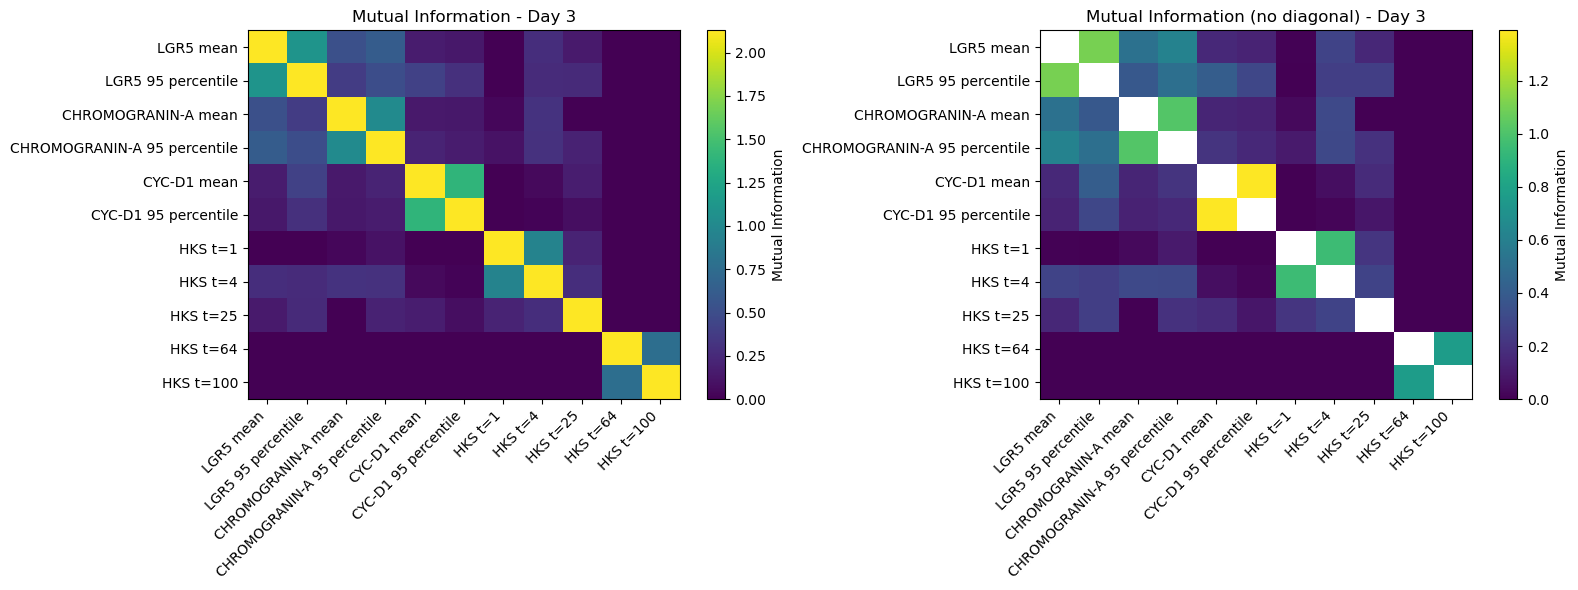

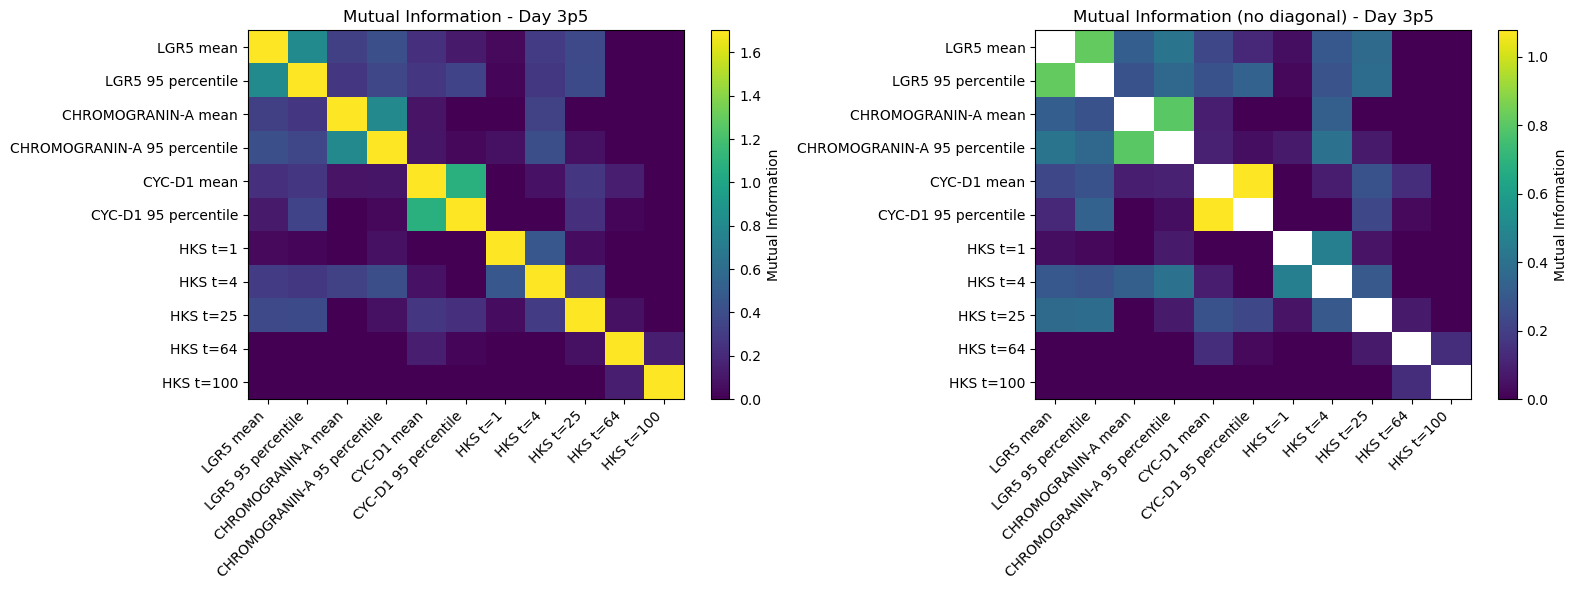

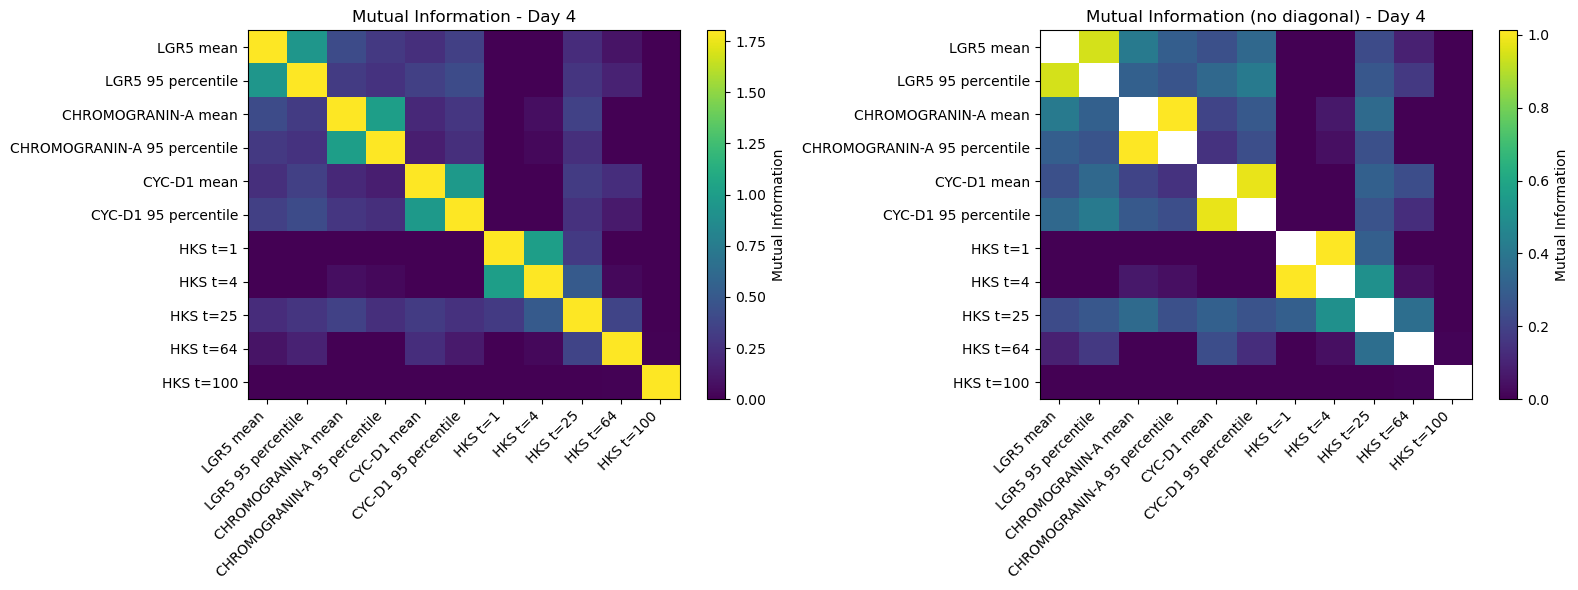

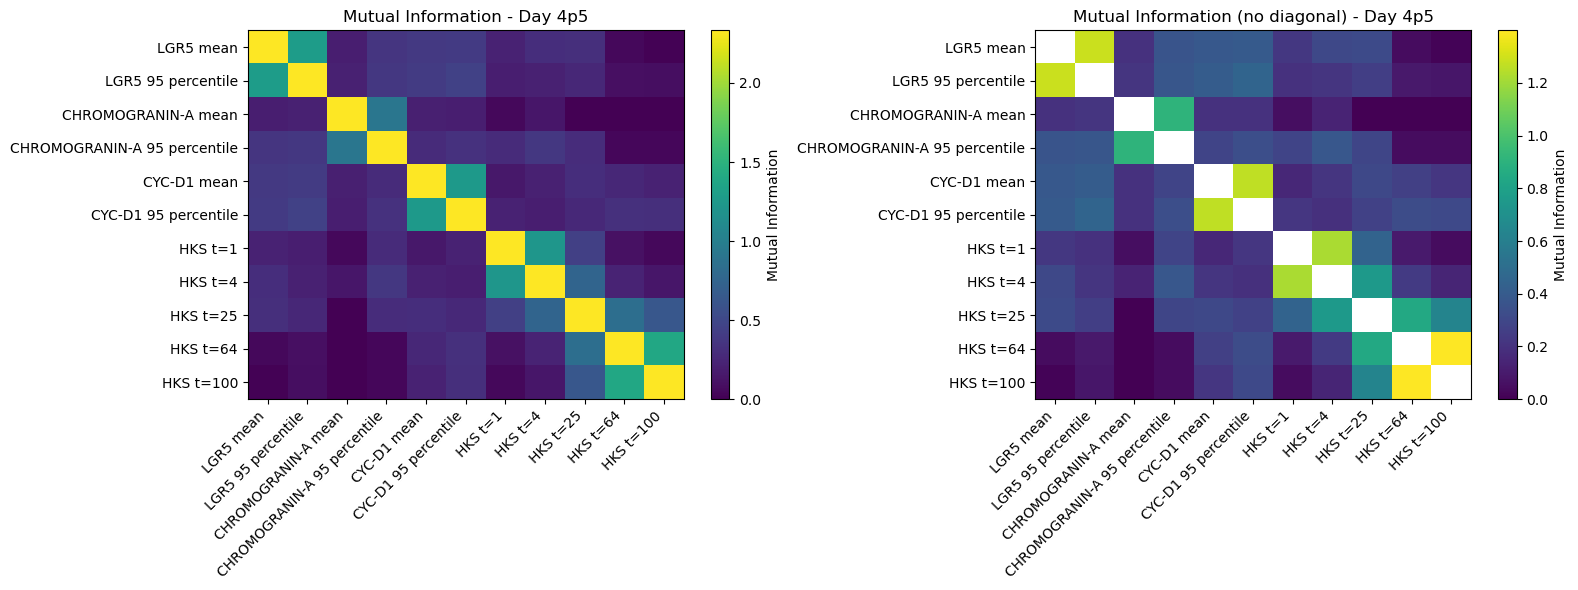

In [77]:
# Loop over all matrices for each timepoint
unique_times_list = np.unique(times)
n_timepoints = len(unique_times_list)

for idx, (mi_matrix, timepoint) in enumerate(zip(matrices, unique_times_list)):
    n_features = mi_matrix.shape[0]
    
    # Create subplots: 2 columns (with and without diagonal)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: With diagonal elements
    im1 = ax1.imshow(mi_matrix, cmap='viridis', aspect='auto')
    plt.colorbar(im1, ax=ax1, label='Mutual Information')
    ax1.set_xticks(ticks=np.arange(n_features))
    ax1.set_xticklabels(names, rotation=45, ha='right')
    ax1.set_yticks(ticks=np.arange(n_features))
    ax1.set_yticklabels(names)
    ax1.set_title(f'Mutual Information - Day {timepoint}')
    
    # Plot 2: Without diagonal elements
    mask = np.eye(n_features, dtype=bool)
    mi_matrix_masked = np.copy(mi_matrix)
    mi_matrix_masked[mask] = np.nan
    
    im2 = ax2.imshow(mi_matrix_masked, cmap='viridis', aspect='auto')
    plt.colorbar(im2, ax=ax2, label='Mutual Information')
    ax2.set_xticks(ticks=np.arange(n_features))
    ax2.set_xticklabels(names, rotation=45, ha='right')
    ax2.set_yticks(ticks=np.arange(n_features))
    ax2.set_yticklabels(names)
    ax2.set_title(f'Mutual Information (no diagonal) - Day {timepoint}')
    
    plt.tight_layout()
    plt.show()

(341, 11)


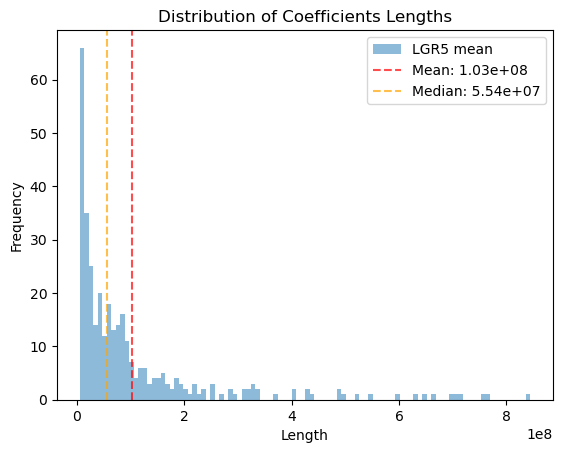

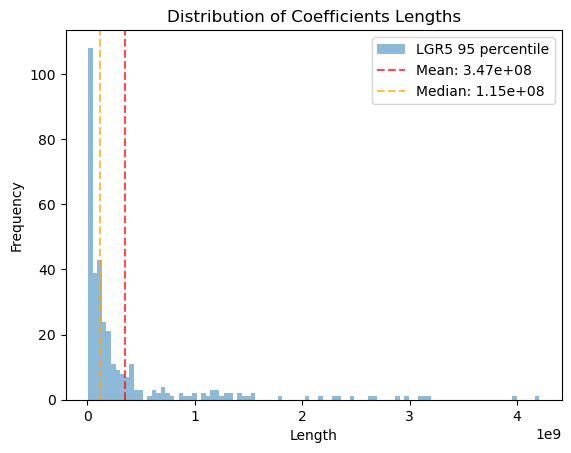

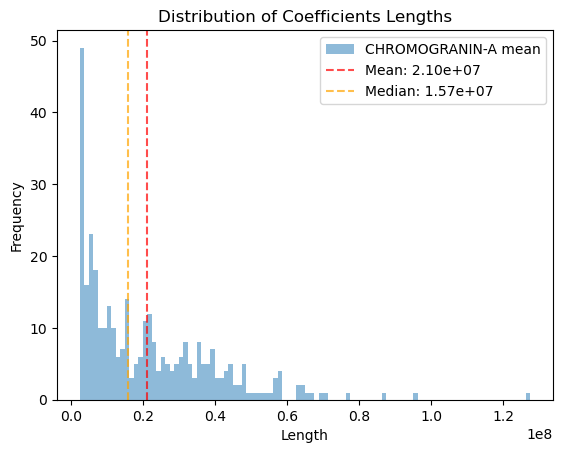

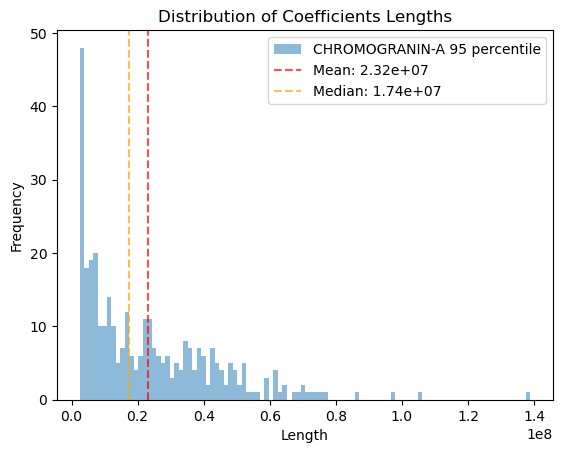

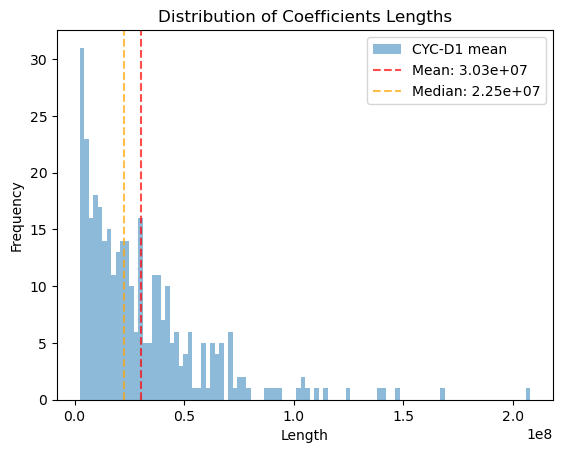

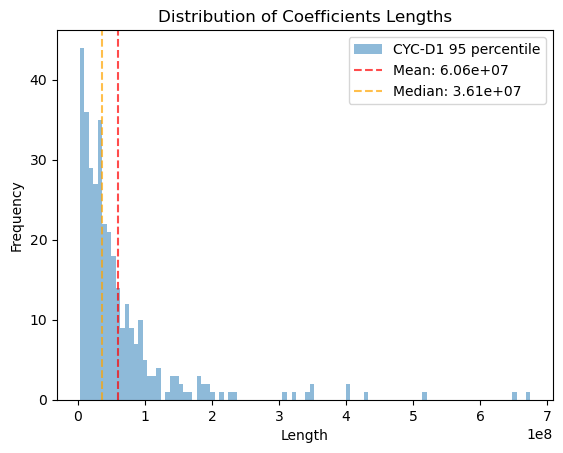

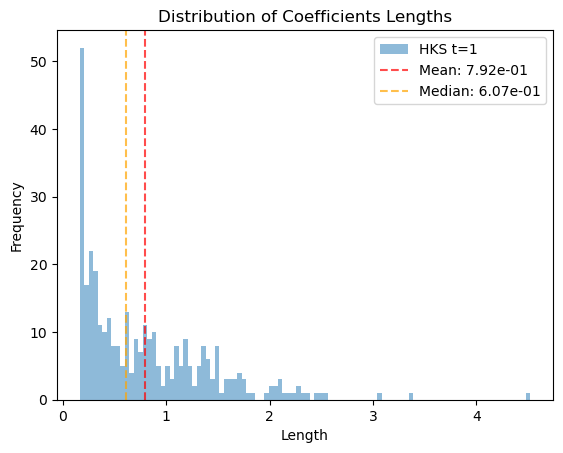

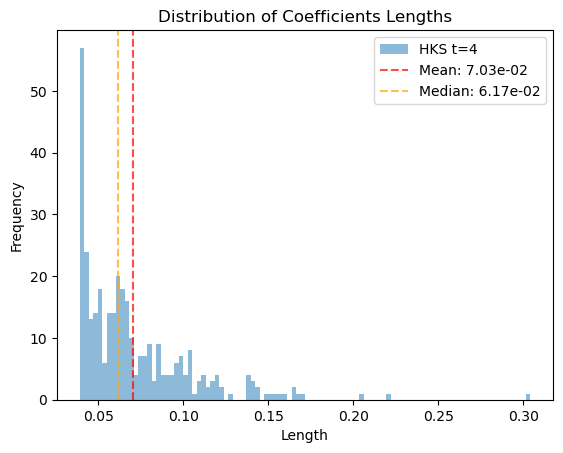

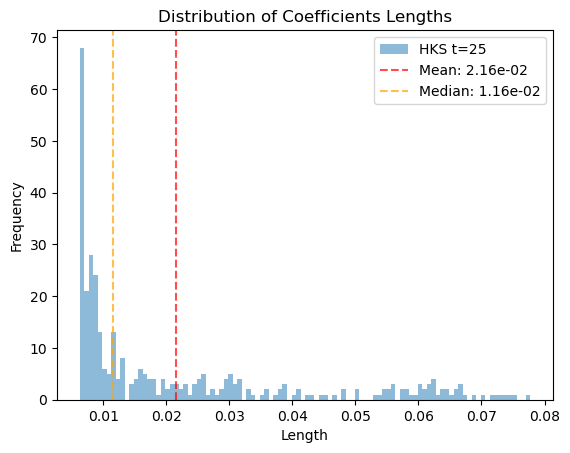

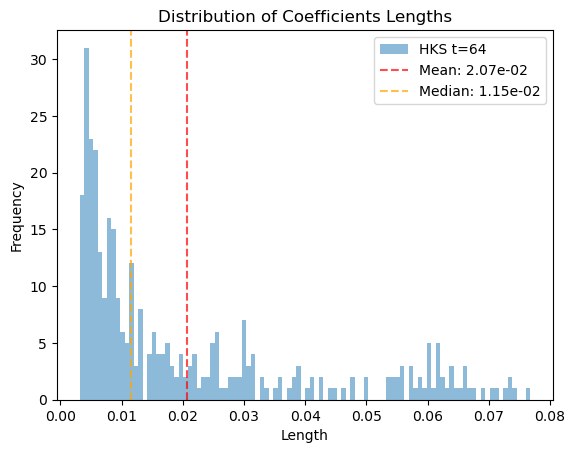

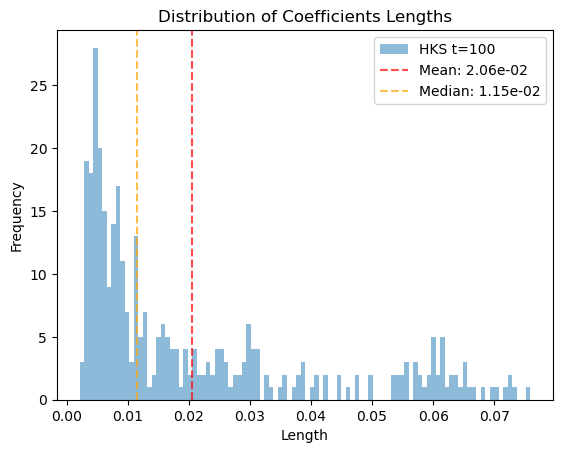

In [78]:
weights = np.sqrt(compute_weights(lmax=15))
lengths = np.sum(coeffs * np.conjugate(coeffs) * weights[np.newaxis, :, np.newaxis], axis=1) 


print(lengths.shape) 
for i in range(coeffs.shape[-1]):
    plt.hist(lengths[:, i], bins=100, alpha=0.5, label=names[i])
    plt.axvline(np.mean(lengths[:, i]), color='red', linestyle='--', alpha=0.7, label=f'Mean: {np.mean(lengths[:, i]):.2e}')
    plt.axvline(np.median(lengths[:, i]), color='orange', linestyle='--', alpha=0.7, label=f'Median: {np.median(lengths[:, i]):.2e}')
    plt.xlabel('Length')
    plt.ylabel('Frequency')
    plt.title('Distribution of Coefficients Lengths')
    plt.legend()
    plt.show()